In [ ]:
# Required Libraries
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

In [ ]:
train = pd.read_csv("/content/drive/MyDrive/CI/train.csv")
test = pd.read_csv("/content/drive/MyDrive/CI/test.csv")

In [ ]:
train.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [ ]:
test['loan_grade'].unique()

array(['F', 'C', 'E', 'A', 'D', 'B', 'G'], dtype=object)

In [ ]:
train['cb_person_cred_hist_length'].max()

30

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [ ]:
# Display missing values
print("Missing values in training data:\n", train.isnull().sum())

Missing values in training data:
 id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


<Axes: >

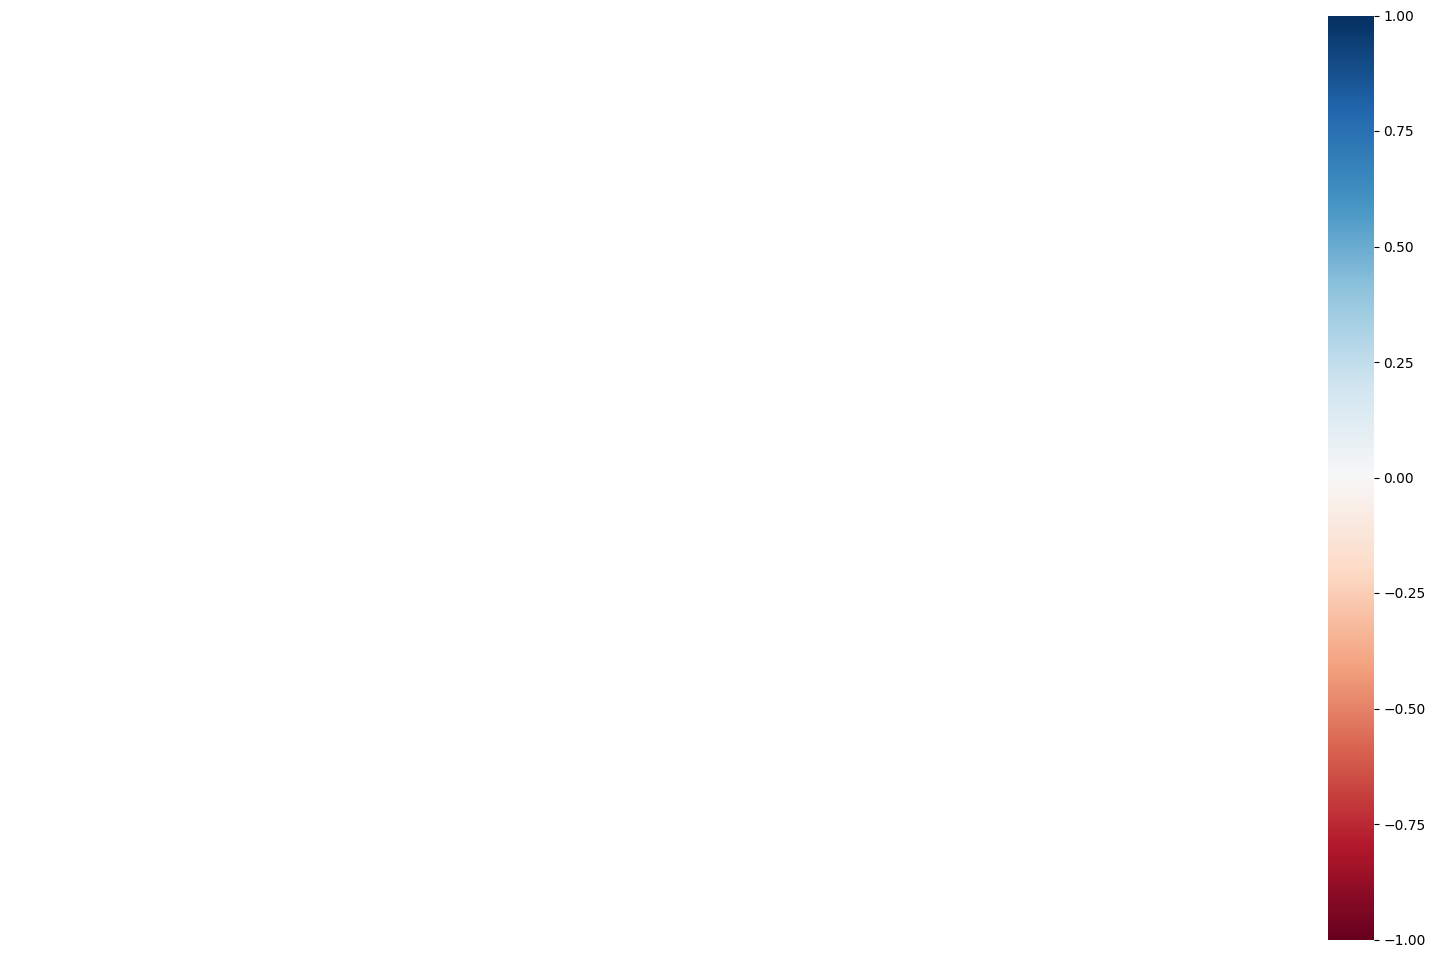

In [ ]:
# Generate a missing values heatmap
msno.heatmap(train)

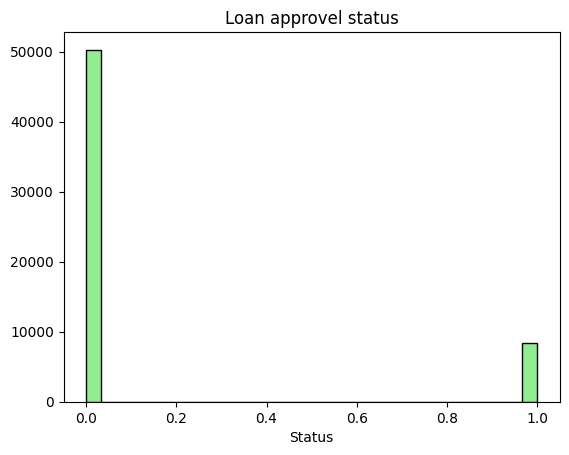

In [ ]:
# Create the histogram
plt.hist(train['loan_status'], bins=30, color='lightgreen', edgecolor='black')
plt.xlabel("Status")
plt.title("Loan approvel status")
plt.show()

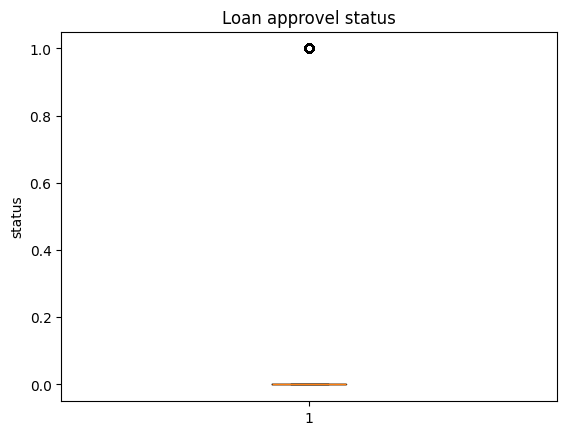

In [ ]:
# Create a box plot
plt.boxplot(train['loan_status'])
plt.title('Loan approvel status')
plt.ylabel('status')
plt.show()


In [ ]:
test['loan_grade'].unique()

array(['F', 'C', 'E', 'A', 'D', 'B', 'G'], dtype=object)

In [ ]:
# Encode Categorical Features
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

label_encoders = {}
encoder = LabelEncoder()
for col in categorical_cols:
    train[col] = encoder.fit_transform(train[col])
    test[col] = encoder.transform(test[col])
    print(f"Encoded {col}:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))
    label_encoders[col] = encoder

Encoded person_home_ownership: {'MORTGAGE': np.int64(0), 'OTHER': np.int64(1), 'OWN': np.int64(2), 'RENT': np.int64(3)}
Encoded loan_intent: {'DEBTCONSOLIDATION': np.int64(0), 'EDUCATION': np.int64(1), 'HOMEIMPROVEMENT': np.int64(2), 'MEDICAL': np.int64(3), 'PERSONAL': np.int64(4), 'VENTURE': np.int64(5)}
Encoded loan_grade: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'E': np.int64(4), 'F': np.int64(5), 'G': np.int64(6)}
Encoded cb_person_default_on_file: {'N': np.int64(0), 'Y': np.int64(1)}


In [ ]:
joblib.dump(label_encoders, '/content/drive/MyDrive/CI/label_encoders.pkl')

['/content/drive/MyDrive/CI/label_encoders.pkl']

In [ ]:
test['loan_grade'].unique()

array([5, 2, 4, 0, 3, 1, 6])

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  int64  
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  int64  
 6   loan_grade                  58645 non-null  int64  
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  int64  
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(10)
memory

In [ ]:
correlation_matrix = train.corr()

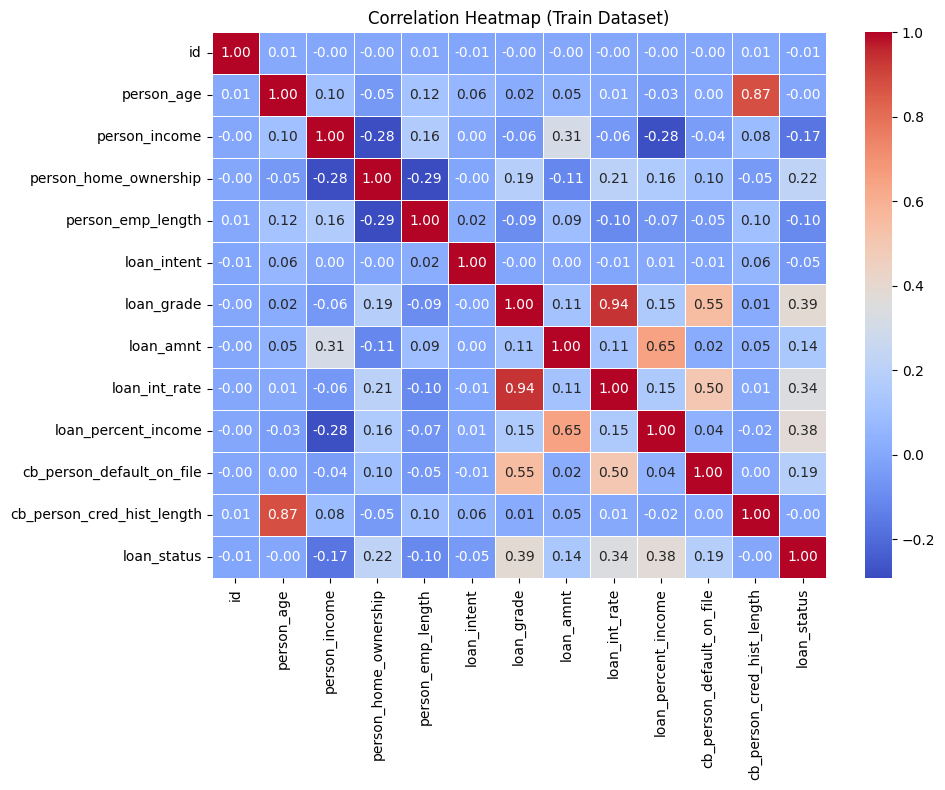

In [ ]:
# correlation heatmap
correlation_matrix = train.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Train Dataset)")
plt.tight_layout()
plt.show()

In [ ]:
# Drop id
train.drop('id', axis=1, inplace=True)
test_ids = test['id']
test.drop('id', axis=1, inplace=True)

In [ ]:
# Features and Target
X = train.drop('loan_status', axis=1)
y = train['loan_status']

In [ ]:
# Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Evaluate on Validation Set
y_pred = lr_model.predict(X_val)
y_pred_binary = [1 if p > 0.5 else 0 for p in y_pred]

print("Validation Accuracy:", accuracy_score(y_val, y_pred_binary))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_binary))
print("Classification Report:\n", classification_report(y_val, y_pred_binary))

Validation Accuracy: 0.8892488703214255
Confusion Matrix:
 [[9982  105]
 [1194  448]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     10087
           1       0.81      0.27      0.41      1642

    accuracy                           0.89     11729
   macro avg       0.85      0.63      0.67     11729
weighted avg       0.88      0.89      0.86     11729



In [ ]:
# Predict on Test Set
test_preds = lr_model.predict(test)
test_preds_binary = ['Y' if x > 0.5 else 'N' for x in test_preds]

In [ ]:
# Create and train Logistic Regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
# Validate the model
y_pred = logreg.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

Validation Accuracy: 0.8940233609003325
Confusion Matrix:
 [[9850  237]
 [1006  636]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94     10087
           1       0.73      0.39      0.51      1642

    accuracy                           0.89     11729
   macro avg       0.82      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729



In [ ]:
# Train Random Forest Classifier
RFmodel = RandomForestClassifier(n_estimators=100, random_state=42)
RFmodel.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Evaluate the model
y_pred = RFmodel.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.949356296359451
Confusion Matrix:
 [[9978  109]
 [ 485 1157]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97     10087
           1       0.91      0.70      0.80      1642

    accuracy                           0.95     11729
   macro avg       0.93      0.85      0.88     11729
weighted avg       0.95      0.95      0.95     11729



In [ ]:
# Train XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:12:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Evaluate the model
y_pred = xgb_model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.9522550942109301
Confusion Matrix:
 [[9949  138]
 [ 422 1220]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97     10087
           1       0.90      0.74      0.81      1642

    accuracy                           0.95     11729
   macro avg       0.93      0.86      0.89     11729
weighted avg       0.95      0.95      0.95     11729



In [ ]:
# Base XGBoost Classifier
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [ ]:
# GridSearchCV parameters
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [ ]:
# Perform grid search
grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:13:52] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100],
                         'subsample': [0.8, 1]},
             verbose=1)

In [ ]:
# Best model
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1}


In [ ]:
# Evaluate on validation
y_pred = best_model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.9528519055332936
Confusion Matrix:
 [[9972  115]
 [ 438 1204]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97     10087
           1       0.91      0.73      0.81      1642

    accuracy                           0.95     11729
   macro avg       0.94      0.86      0.89     11729
weighted avg       0.95      0.95      0.95     11729



In [ ]:
import pickle
with open('/content/drive/MyDrive/CI/loan_pred_xgboost.pkl', 'wb') as file:
    pickle.dump(best_model, file)

In [ ]:
# Predict on Kaggle test dataset
test_preds = best_model.predict(test)

In [ ]:
# Submission
submission = pd.DataFrame({
    'id': test_ids,
    'loan_status': test_preds
})
submission.to_csv("/content/drive/MyDrive/CI/submission_xgboost_tuned.csv", index=False)
print("Submission saved as: submission_xgboost_tuned.csv")

Submission saved as: submission_xgboost_tuned.csv
